<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Transmon_Family_Tree_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [11]:
!uv pip install --system -q networkx graphviz pillow pydot

NetworkX validation passed: 45 nodes, 44 directed edges, and numbered entries 01 through 30 are complete.


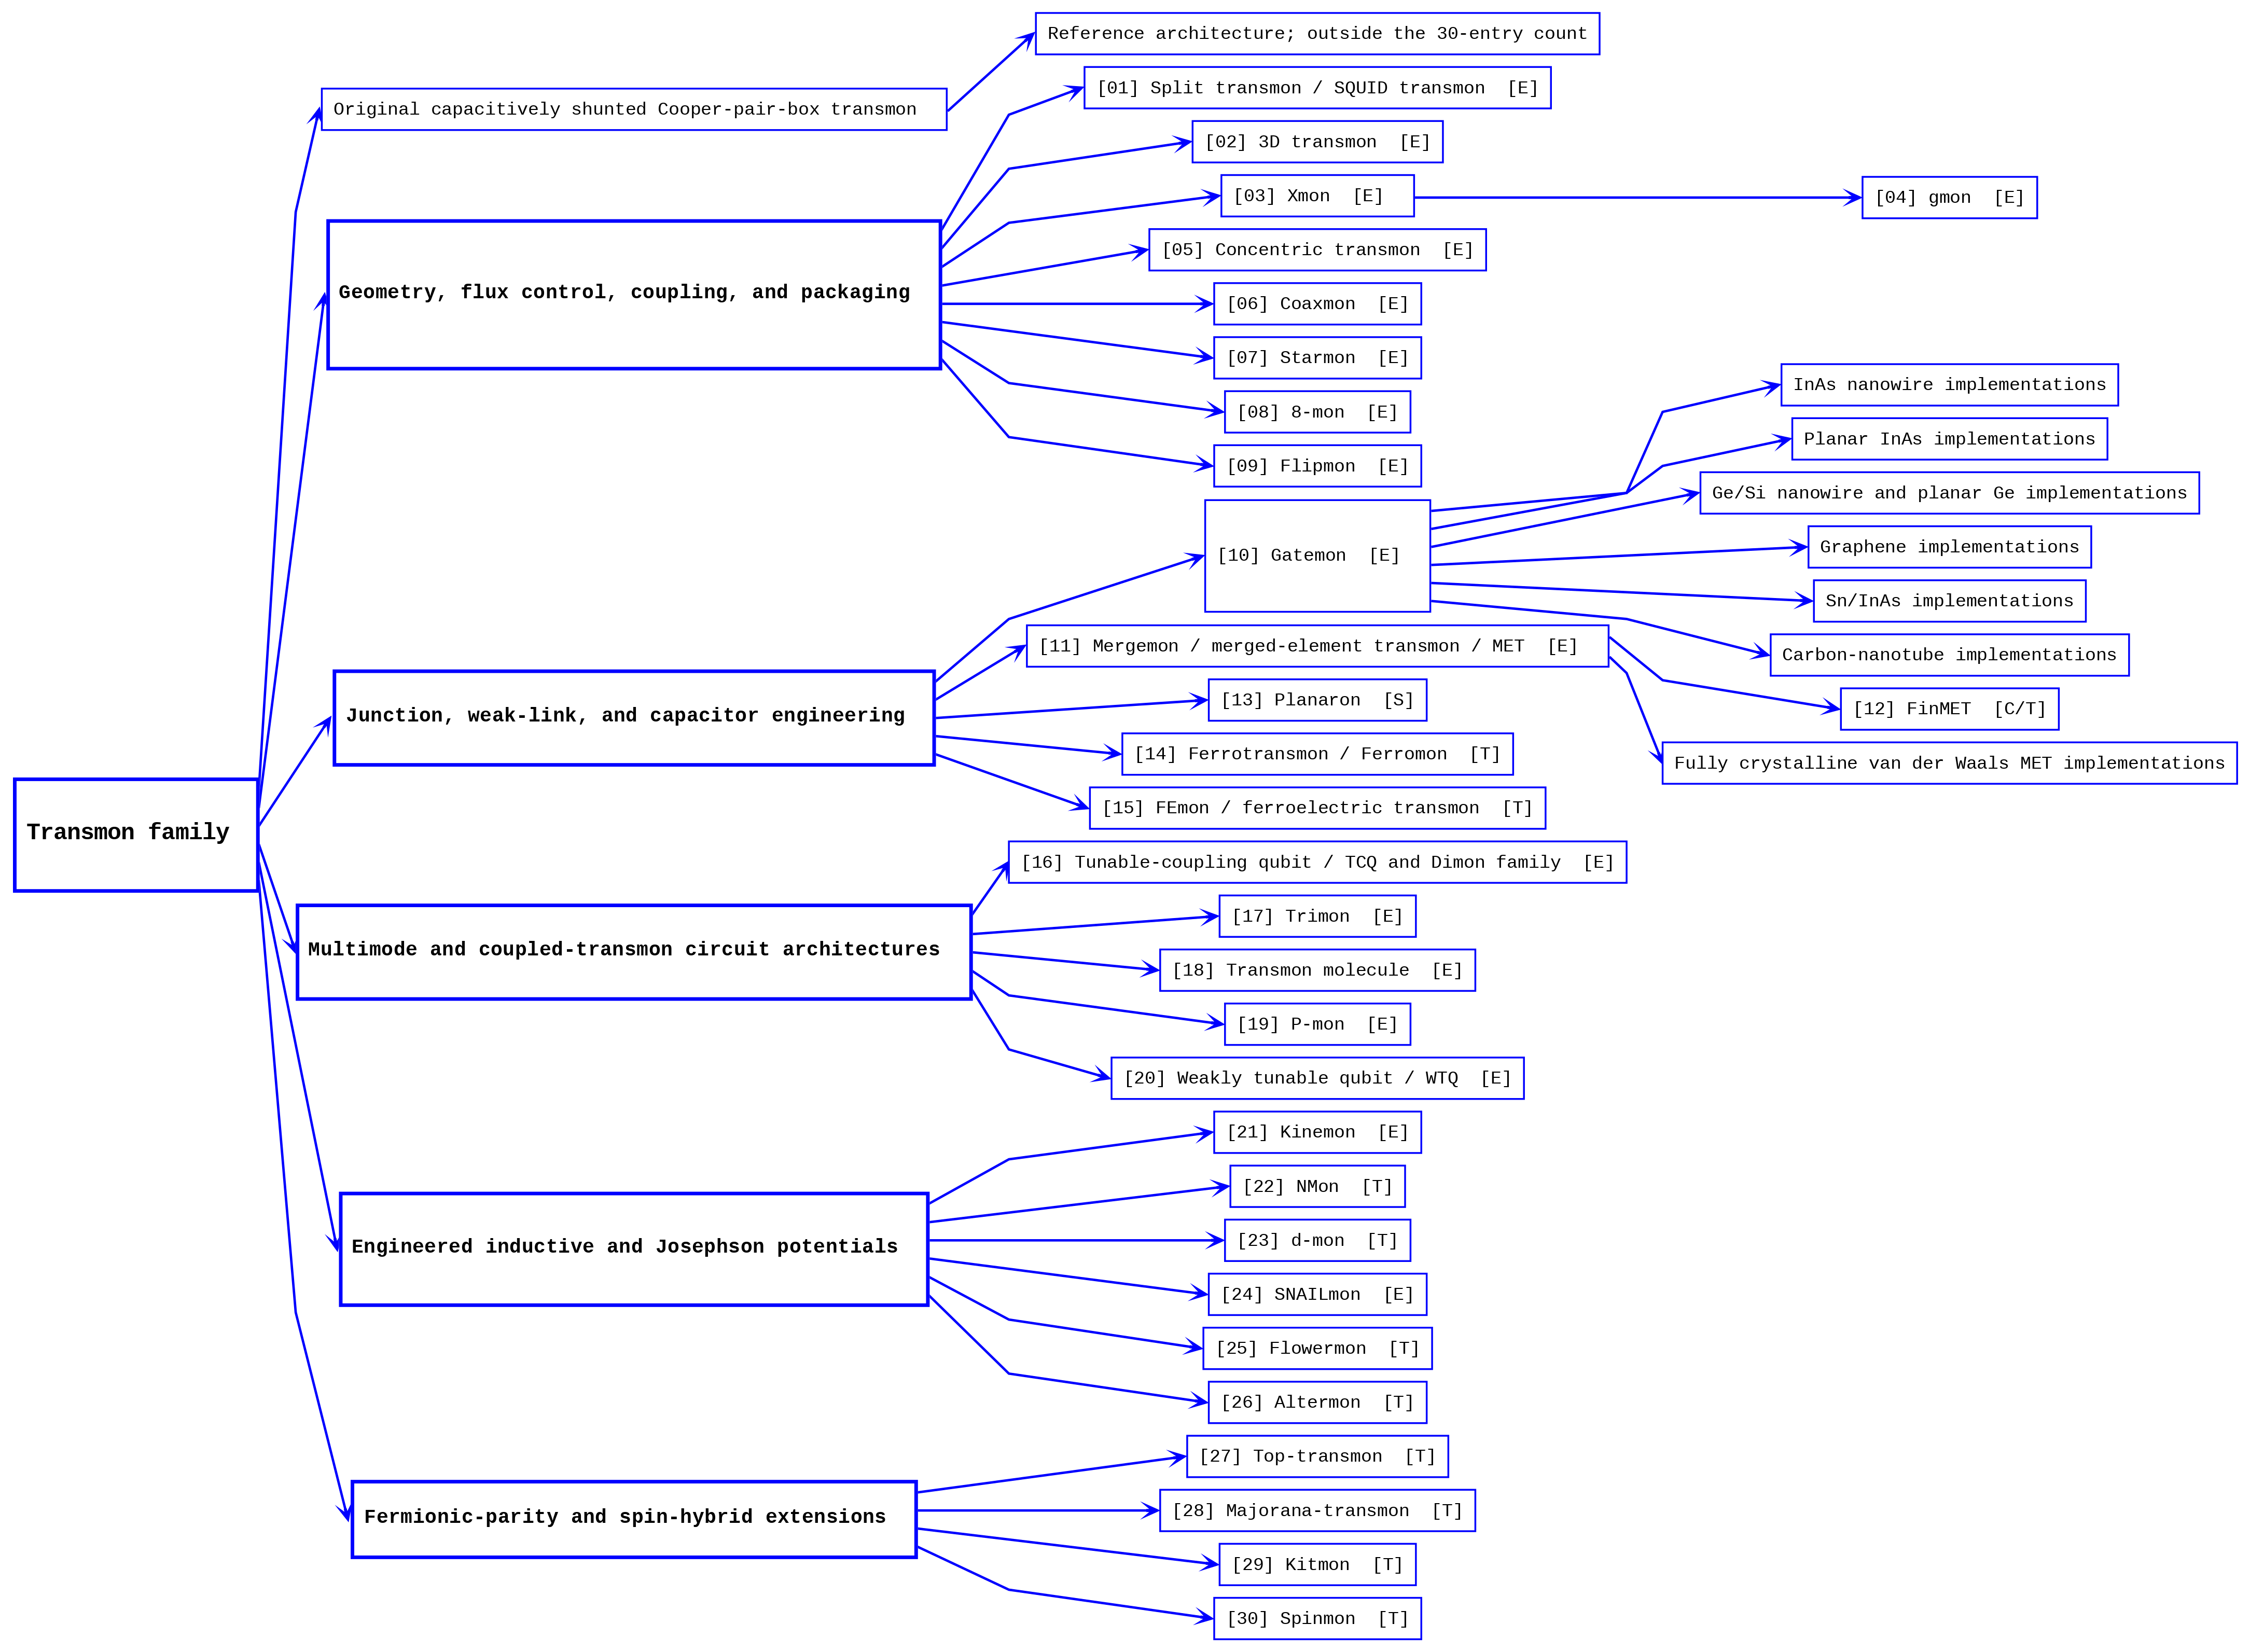

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PNG written to: /content/transmon_family_tree.png


In [14]:
"""Transmon-family tree with NetworkX and Graphviz."""

import html
import re
from dataclasses import dataclass
from pathlib import Path

import networkx as nx
from graphviz import Digraph
from IPython.display import Image as IPythonImage
from IPython.display import display


# - Control knobs -
PURE_BLUE = "#0000FF"
BLACK = "#000000"
WHITE = "#FFFFFF"

OUTPUT_PNG = Path("/content/transmon_family_tree.png")
GRAPH_DPI = 250
DISPLAY_WIDTH_PX = 1800

FONT_NAME = "DejaVu Sans"
FONT_SIZE_PT = 10
CATEGORY_FONT_SIZE_PT = 11
ROOT_FONT_SIZE_PT = 13

RANK_SEPARATION_IN = 0.28
NODE_SEPARATION_IN = 0.10
PORT_CELL_HEIGHT_PT = 6
PORT_CELL_WIDTH_PT = 4

EDGE_WIDTH_PT = 1.35
ARROW_SIZE = 0.55


@dataclass(frozen=True)
class NodeSpec:
    """Describe one semantic node in the transmon-family tree.

    Attributes:
        node_id: Stable internal identifier used by NetworkX and Graphviz.
        label: Human-readable node label.
        kind: Visual role, such as root, category, entry, reference, or note.
    """

    node_id: str
    label: str
    kind: str = "entry"


def add_branch(
    graph: nx.DiGraph,
    parent: NodeSpec,
    children: list[NodeSpec],
) -> None:
    """Add an ordered parent-to-children branch to the NetworkX graph.

    Args:
        graph: Directed graph receiving the branch.
        parent: Parent node specification.
        children: Child node specifications in the intended display order.
    """
    graph.add_node(parent.node_id, label=parent.label, kind=parent.kind)

    for order, child in enumerate(children):
        graph.add_node(child.node_id, label=child.label, kind=child.kind)
        graph.add_edge(parent.node_id, child.node_id, order=order)


def build_transmon_tree() -> nx.DiGraph:
    """Build the transmon-family topology as a directed NetworkX tree.

    Returns:
        A directed graph whose edges encode parent-to-child relationships.
    """
    graph = nx.DiGraph()

    root = NodeSpec("root", "Transmon family", "root")
    original = NodeSpec(
        "original",
        "Original capacitively shunted Cooper-pair-box transmon",
        "reference",
    )
    geometry = NodeSpec(
        "geometry",
        "Geometry, flux control, coupling, and packaging",
        "category",
    )
    junction = NodeSpec(
        "junction",
        "Junction, weak-link, and capacitor engineering",
        "category",
    )
    multimode = NodeSpec(
        "multimode",
        "Multimode and coupled-transmon circuit architectures",
        "category",
    )
    inductive = NodeSpec(
        "inductive",
        "Engineered inductive and Josephson potentials",
        "category",
    )
    fermionic = NodeSpec(
        "fermionic",
        "Fermionic-parity and spin-hybrid extensions",
        "category",
    )

    add_branch(
        graph,
        root,
        [original, geometry, junction, multimode, inductive, fermionic],
    )

    add_branch(
        graph,
        original,
        [
            NodeSpec(
                "reference_note",
                "Reference architecture; outside the 30-entry count",
                "note",
            )
        ],
    )

    add_branch(
        graph,
        geometry,
        [
            NodeSpec("n01", "[01] Split transmon / SQUID transmon  [E]"),
            NodeSpec("n02", "[02] 3D transmon  [E]"),
            NodeSpec("n03", "[03] Xmon  [E]"),
            NodeSpec("n05", "[05] Concentric transmon  [E]"),
            NodeSpec("n06", "[06] Coaxmon  [E]"),
            NodeSpec("n07", "[07] Starmon  [E]"),
            NodeSpec("n08", "[08] 8-mon  [E]"),
            NodeSpec("n09", "[09] Flipmon  [E]"),
        ],
    )
    add_branch(
        graph,
        NodeSpec("n03", "[03] Xmon  [E]"),
        [NodeSpec("n04", "[04] gmon  [E]")],
    )

    add_branch(
        graph,
        junction,
        [
            NodeSpec("n10", "[10] Gatemon  [E]"),
            NodeSpec(
                "n11",
                "[11] Mergemon / merged-element transmon / MET  [E]",
            ),
            NodeSpec("n13", "[13] Planaron  [S]"),
            NodeSpec("n14", "[14] Ferrotransmon / Ferromon  [T]"),
            NodeSpec("n15", "[15] FEmon / ferroelectric transmon  [T]"),
        ],
    )
    add_branch(
        graph,
        NodeSpec("n10", "[10] Gatemon  [E]"),
        [
            NodeSpec("g_inas_wire", "InAs nanowire implementations", "note"),
            NodeSpec("g_inas_planar", "Planar InAs implementations", "note"),
            NodeSpec(
                "g_ge",
                "Ge/Si nanowire and planar Ge implementations",
                "note",
            ),
            NodeSpec("g_graphene", "Graphene implementations", "note"),
            NodeSpec("g_sn_inas", "Sn/InAs implementations", "note"),
            NodeSpec(
                "g_cnt",
                "Carbon-nanotube implementations",
                "note",
            ),
        ],
    )
    add_branch(
        graph,
        NodeSpec(
            "n11",
            "[11] Mergemon / merged-element transmon / MET  [E]",
        ),
        [
            NodeSpec("n12", "[12] FinMET  [C/T]"),
            NodeSpec(
                "vdw_met",
                "Fully crystalline van der Waals MET implementations",
                "note",
            ),
        ],
    )

    add_branch(
        graph,
        multimode,
        [
            NodeSpec(
                "n16",
                "[16] Tunable-coupling qubit / TCQ and Dimon family  [E]",
            ),
            NodeSpec("n17", "[17] Trimon  [E]"),
            NodeSpec("n18", "[18] Transmon molecule  [E]"),
            NodeSpec("n19", "[19] P-mon  [E]"),
            NodeSpec("n20", "[20] Weakly tunable qubit / WTQ  [E]"),
        ],
    )

    add_branch(
        graph,
        inductive,
        [
            NodeSpec("n21", "[21] Kinemon  [E]"),
            NodeSpec("n22", "[22] NMon  [T]"),
            NodeSpec("n23", "[23] d-mon  [T]"),
            NodeSpec("n24", "[24] SNAILmon  [E]"),
            NodeSpec("n25", "[25] Flowermon  [T]"),
            NodeSpec("n26", "[26] Altermon  [T]"),
        ],
    )

    add_branch(
        graph,
        fermionic,
        [
            NodeSpec("n27", "[27] Top-transmon  [T]"),
            NodeSpec("n28", "[28] Majorana-transmon  [T]"),
            NodeSpec("n29", "[29] Kitmon  [T]"),
            NodeSpec("n30", "[30] Spinmon  [T]"),
        ],
    )

    return graph


def ordered_children(graph: nx.DiGraph, node_id: str) -> list[str]:
    """Return a node's children in the explicitly stored branch order.

    Args:
        graph: Directed transmon-family graph.
        node_id: Parent node identifier.

    Returns:
        Child identifiers sorted by the edge-order attribute.
    """
    ordered_edges = sorted(
        graph.out_edges(node_id, data=True),
        key=lambda edge: edge[2]["order"],
    )
    return [child for _, child, _ in ordered_edges]


def validate_transmon_tree(graph: nx.DiGraph) -> None:
    """Validate topology, reachability, and numbered transmon entries.

    Args:
        graph: Directed transmon-family graph to validate.

    Raises:
        ValueError: If the graph is not a rooted arborescence or if entries
            01 through 30 are incomplete or duplicated.
    """
    if not nx.is_arborescence(graph):
        raise ValueError(
            "NetworkX validation failed: the topology is not one rooted tree."
        )

    roots = [node for node, degree in graph.in_degree() if degree == 0]
    if roots != ["root"]:
        raise ValueError(f"Expected only 'root' as the root node; got {roots}.")

    numbered_entries = []
    for _, data in graph.nodes(data=True):
        match = re.match(r"\[(\d{2})\]", data["label"])
        if match:
            numbered_entries.append(int(match.group(1)))

    expected_entries = list(range(1, 31))
    if sorted(numbered_entries) != expected_entries:
        raise ValueError(
            "Expected exactly one copy of every numbered entry 01 through 30."
        )


def make_html_node_label(
    text: str,
    child_count: int,
    kind: str,
) -> str:
    """Create an HTML Graphviz node with independent output edge ports.

    Each child receives a unique east-side port. This keeps sibling arrows
    separated at their source and gives the layout engine distinct routing
    lanes instead of allowing several connectors to share one centerline.

    Args:
        text: Display text inside the node.
        child_count: Number of outgoing child edges.
        kind: Node visual role.

    Returns:
        A Graphviz HTML-like label string.
    """
    safe_text = html.escape(text)

    if kind == "root":
        font_size = ROOT_FONT_SIZE_PT
        border_width = 2
        bold_open, bold_close = "<B>", "</B>"
    elif kind == "category":
        font_size = CATEGORY_FONT_SIZE_PT
        border_width = 2
        bold_open, bold_close = "<B>", "</B>"
    else:
        font_size = FONT_SIZE_PT
        border_width = 1
        bold_open = bold_close = ""

    rows = [
        (
            f'<TABLE BORDER="{border_width}" CELLBORDER="0" '
            f'CELLSPACING="0" CELLPADDING="5" COLOR="{PURE_BLUE}" '
            f'BGCOLOR="{WHITE}">'
        )
    ]

    if child_count:
        rows.append(
            f'<TR><TD ROWSPAN="{child_count}">'
            f'<FONT FACE="{FONT_NAME}" COLOR="{BLACK}" '
            f'POINT-SIZE="{font_size}">'
            f"{bold_open}{safe_text}{bold_close}</FONT></TD>"
            f'<TD PORT="p0" WIDTH="{PORT_CELL_WIDTH_PT}" '
            f'HEIGHT="{PORT_CELL_HEIGHT_PT}"></TD></TR>'
        )
        for index in range(1, child_count):
            rows.append(
                f'<TR><TD PORT="p{index}" WIDTH="{PORT_CELL_WIDTH_PT}" '
                f'HEIGHT="{PORT_CELL_HEIGHT_PT}"></TD></TR>'
            )
    else:
        rows.append(
            f'<TR><TD><FONT FACE="{FONT_NAME}" COLOR="{BLACK}" '
            f'POINT-SIZE="{font_size}">'
            f"{bold_open}{safe_text}{bold_close}</FONT></TD></TR>"
        )

    rows.append("</TABLE>")
    return "<" + "".join(rows) + ">"


def build_graphviz_tree(graph: nx.DiGraph) -> Digraph:
    """Translate the validated NetworkX tree into a compact Graphviz tree.

    The layout uses DOT's hierarchical ranking, explicit sibling ordering,
    unique parent-side ports, and polyline routing. The combination prevents
    shared arrow trunks and keeps connector paths shorter than orthogonal
    right-angle routing for this dense hierarchy.

    Args:
        graph: Validated NetworkX transmon-family tree.

    Returns:
        Configured Graphviz directed graph.
    """
    dot = Digraph("transmon_family", engine="dot", format="png")
    dot.attr(
        "graph",
        rankdir="LR",
        bgcolor=WHITE,
        splines="polyline",
        ordering="out",
        overlap="false",
        concentrate="false",
        outputorder="edgesfirst",
        newrank="true",
        remincross="true",
        nodesep=str(NODE_SEPARATION_IN),
        ranksep=str(RANK_SEPARATION_IN),
        pad="0.08",
        margin="0.02",
        dpi=str(GRAPH_DPI),
    )
    dot.attr("node", shape="plain", fontname=FONT_NAME)
    dot.attr(
        "edge",
        color=PURE_BLUE,
        penwidth=str(EDGE_WIDTH_PT),
        arrowsize=str(ARROW_SIZE),
        arrowhead="vee",
    )

    topological_order = list(nx.topological_sort(graph))

    # Add the complete node geometry before any edges are routed.
    for node_id in topological_order:
        node_data = graph.nodes[node_id]
        children = ordered_children(graph, node_id)
        dot.node(
            node_id,
            label=make_html_node_label(
                node_data["label"],
                len(children),
                node_data["kind"],
            ),
        )

    # Give every sibling edge a distinct source port. The tree topology has
    # one parent per non-root node, eliminating edge-merging at child nodes.
    for parent_id in topological_order:
        children = ordered_children(graph, parent_id)
        for port_index, child_id in enumerate(children):
            dot.edge(
                f"{parent_id}:p{port_index}:e",
                f"{child_id}:w",
                minlen="1",
                weight="2",
            )

    return dot


def render_display_and_download(dot: Digraph) -> Path:
    """Render the graph in memory, display it, save it, and download it.

    Args:
        dot: Configured Graphviz graph.

    Returns:
        Path to the saved PNG inside the Colab runtime.
    """
    png_bytes = dot.pipe(format="png")

    # Display directly from bytes, so visualization happens in memory first.
    display(IPythonImage(data=png_bytes, width=DISPLAY_WIDTH_PX))

    OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT_PNG.write_bytes(png_bytes)

    try:
        from google.colab import files

        files.download(str(OUTPUT_PNG))
    except ImportError:
        print(f"Saved PNG: {OUTPUT_PNG}")

    return OUTPUT_PNG


def main() -> None:
    """Build, validate, render, display, and download the transmon tree."""
    graph = build_transmon_tree()
    validate_transmon_tree(graph)

    print(
        "NetworkX validation passed: "
        f"{graph.number_of_nodes()} nodes, "
        f"{graph.number_of_edges()} directed edges, "
        "and numbered entries 01 through 30 are complete."
    )

    dot = build_graphviz_tree(graph)
    output_path = render_display_and_download(dot)
    print(f"PNG written to: {output_path}")

if __name__ == "__main__":
    main()